<a href="https://colab.research.google.com/github/Frendy9/project-akhir-machine-learning-semester4/blob/main/MACHINE_LEARNING_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gdown 1GXvz1sTkV_qpfVhPhnNirDlthz-r_s3S

Downloading...
From (original): https://drive.google.com/uc?id=1GXvz1sTkV_qpfVhPhnNirDlthz-r_s3S
From (redirected): https://drive.google.com/uc?id=1GXvz1sTkV_qpfVhPhnNirDlthz-r_s3S&confirm=t&uuid=2423aec9-c841-4d45-b21b-35a7b8491845
To: /content/solarPV.csv
100% 596M/596M [00:12<00:00, 45.9MB/s]


In [ ]:
import pandas as pd

df = pd.read_csv('solarPV.csv')
df.head()

,Time,AL00,AT00,AT01,AT02,AT03,BA00,BE00,BE01,BE02,...,UA01,UA02,UK00,UK01,UK02,UK03,UK04,UK05,UKNI,XK00
0,01-Jan-1982 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,01-Jan-1982 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,01-Jan-1982 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,01-Jan-1982 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,01-Jan-1982 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

LOOKBACK   = 24          # jam lookback
HORIZON    = 1           # jam ke depan
BATCH_SIZE = 64
EPOCHS     = 100

# Ubah bagian DATA_PATH menjadi seperti ini:
DATA_PATH  = "solarPV.csv"  # Cukup nama filenya saja
TARGET_COL = "UK00"         # Kolom wilayah yang ingin diprediksi

In [ ]:
def plot_eda(df: pd.DataFrame) -> None:
    """Distribusi, tren, dan pola musiman target."""
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # (a) Distribusi
    ax0 = fig.add_subplot(gs[0, 0])
    df["target"].hist(bins=60, ax=ax0, color="#4C72B0", edgecolor="white")
    ax0.set(title="Distribusi Target", xlabel="Target", ylabel="Frekuensi")

    # (b) Time-series keseluruhan
    ax1 = fig.add_subplot(gs[0, 1])
    df["target"].plot(ax=ax1, linewidth=0.6, color="#DD8452")
    ax1.set(title="Tren Keseluruhan", xlabel="Datetime", ylabel="Target")

    # (c) Rata-rata per jam (pola harian)
    ax2 = fig.add_subplot(gs[1, 0])
    df.groupby("hour")["target"].mean().plot(kind="bar", ax=ax2, color="#55A868")
    ax2.set(title="Rata-rata per Jam", xlabel="Jam", ylabel="Target")

    # (d) Rata-rata per bulan (pola bulanan)
    ax3 = fig.add_subplot(gs[1, 1])
    df.groupby("month")["target"].mean().plot(kind="bar", ax=ax3, color="#C44E52")
    ax3.set(title="Rata-rata per Bulan", xlabel="Bulan", ylabel="Target")

    # (e) Boxplot per musim
    ax4 = fig.add_subplot(gs[2, 0])
    season_order = ["Spring","Summer","Fall","Winter"]
    sns.boxplot(data=df, x="season", y="target", order=season_order,
                palette="Set2", ax=ax4)
    ax4.set(title="Distribusi per Musim", xlabel="Musim", ylabel="Target")

    # (f) Boxplot per jam
    ax5 = fig.add_subplot(gs[2, 1])
    sns.boxplot(data=df, x="hour", y="target", palette="coolwarm", ax=ax5)
    ax5.set(title="Distribusi per Jam", xlabel="Jam", ylabel="Target")
    ax5.tick_params(axis="x", labelsize=7)

    plt.suptitle("Exploratory Data Analysis – Solar PV", fontsize=15, fontweight="bold")
    plt.show()

In [ ]:
def get_season(month: int) -> str:
    return {12:"Winter", 1:"Winter", 2:"Winter",
             3:"Spring", 4:"Spring", 5:"Spring",
             6:"Summer", 7:"Summer", 8:"Summer",
             9:"Fall", 10:"Fall", 11:"Fall"}[month]


def preprocess(path: str) -> tuple[pd.DataFrame, MinMaxScaler]:
    """Load, parse, ekstrak fitur, tangani null/outlier, normalisasi."""
    # PERUBAHAN: Parsing kolom 'Time' sesuai isi dataset asli
    df = pd.read_csv(path, parse_dates=["Time"])
    df = df.sort_values("Time").reset_index(drop=True)
    df = df.set_index("Time")

    # PERUBAHAN: Ambil kolom wilayah yang dipilih dan set sebagai kolom 'target'
    if TARGET_COL in df.columns:
        df["target"] = df[TARGET_COL]
    else:
        raise ValueError(f"Kolom wilyah '{TARGET_COL}' tidak ditemukan di dataset. Silakan periksa kembali target Anda.")

    # Tangani null pada kolom target
    df["target"] = df["target"].interpolate(method="time").fillna(method="bfill")

    # Fitur temporal menggunakan indeks Time
    df["hour"]       = df.index.hour
    df["day"]        = df.index.day
    df["month"]      = df.index.month
    df["dayofweek"]  = df.index.dayofweek
    df["season"]     = df["month"].map(get_season)

    # Hapus outlier (IQR 1.5×)
    Q1, Q3 = df["target"].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    mask   = df["target"].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    n_out  = (~mask).sum()
    df.loc[~mask, "target"] = np.nan
    df["target"] = df["target"].interpolate(method="time")
    print(f"[Preprocess] Outlier ditangani: {n_out} titik")

    print(f"[Preprocess] Shape: {df.shape} | Null: {df['target'].isna().sum()}")
    return df, None   # scaler dibuat di sequencing

In [ ]:
FEATURE_COLS = ["target", "hour", "day", "month", "dayofweek"]

def build_sequences(values: np.ndarray,
                    lookback: int = LOOKBACK,
                    horizon: int  = HORIZON):
    """Buat pasangan (X, y) dari array 2-D."""
    X, y = [], []
    for i in range(len(values) - lookback - horizon + 1):
        X.append(values[i : i + lookback])
        y.append(values[i + lookback + horizon - 1, 0])   # kolom-0 = target
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [ ]:
def temporal_split(X: np.ndarray, y: np.ndarray,
                   train_r=0.70, val_r=0.15):
    n       = len(X)
    n_train = int(n * train_r)
    n_val   = int(n * val_r)
    X_tr, y_tr = X[:n_train],            y[:n_train]
    X_va, y_va = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
    X_te, y_te = X[n_train+n_val:],       y[n_train+n_val:]
    print(f"[Split] Train={len(X_tr)} | Val={len(X_va)} | Test={len(X_te)}")
    return (X_tr, y_tr), (X_va, y_va), (X_te, y_te)

=== 1. MENJALANKAN PREPROCESSING ===
[Preprocess] Outlier ditangani: 14834 titik
[Preprocess] Shape: (333096, 185) | Null: 0

=== 2. MENAMPILKAN GRAFIK EDA ===


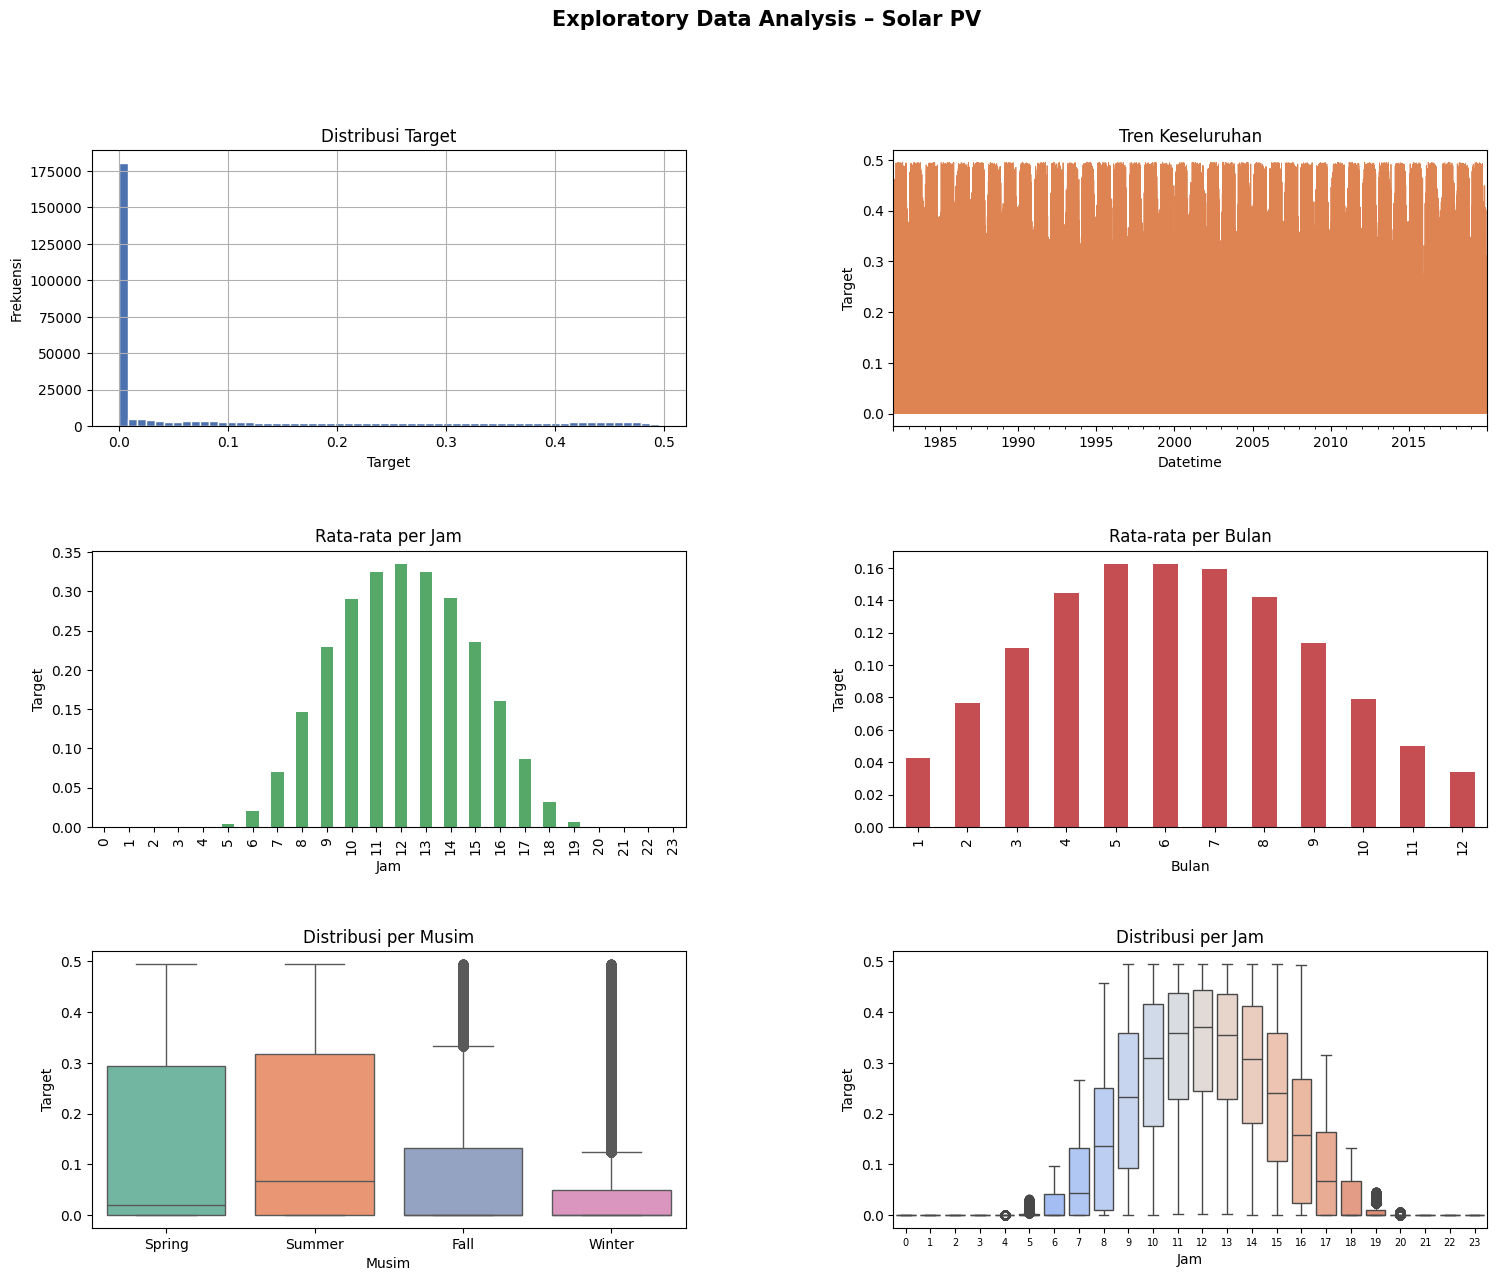


=== 3. MEMBUAT SEQUENCE (SLIDING WINDOW) ===
Shape X (Input Model): (333072, 24, 5) | Shape y (Target Model): (333072,)

=== 4. MEMBAGI DATA BERDASARKAN URUTAN WAKTU ===
[Split] Train=233150 | Val=49960 | Test=49962

=== SELURUH ALUR DATA PIPELINE SELESAI DIJALANKAN ===


In [ ]:
# =====================================================================
# CELL BARU: BLOK EKSEKUSI UTAMA (RUN ALL AT ONCE)
# =====================================================================

# Langkah 1: Jalankan Preprocessing
print("=== 1. MENJALANKAN PREPROCESSING ===")
# Catatan: Pastikan DATA_PATH sudah mengarah ke file Anda (misal: 'solarPV.csv')
df_processed, _ = preprocess(DATA_PATH)

# Langkah 2: Jalankan EDA (Semua grafik akan langsung keluar di sini)
print("\n=== 2. MENAMPILKAN GRAFIK EDA ===")
plot_eda(df_processed)

# Langkah 3: Menyiapkan Fitur dan Membuat Sequence (Sliding Window)
print("\n=== 3. MEMBUAT SEQUENCE (SLIDING WINDOW) ===")
# Ambil matriks nilai berdasarkan FEATURE_COLS yang didefinisikan ["target", "hour", "day", "month", "dayofweek"]
data_values = df_processed[FEATURE_COLS].copy()

# Lakukan normalisasi MinMaxScaler khusus untuk kolom target (kolom indeks 0)
scaler = MinMaxScaler()
data_values["target"] = scaler.fit_transform(data_values[["target"]])

# Ubah menjadi numpy array untuk dimasukkan ke fungsi build_sequences
X, y = build_sequences(data_values.values, lookback=LOOKBACK, horizon=HORIZON)
print(f"Shape X (Input Model): {X.shape} | Shape y (Target Model): {y.shape}")

# Langkah 4: Pembagian Data (Train, Validation, Test Split)
print("\n=== 4. MEMBAGI DATA BERDASARKAN URUTAN WAKTU ===")
(X_train, y_train), (X_val, y_val), (X_test, y_test) = temporal_split(X, y)

print("\n=== SELURUH ALUR DATA PIPELINE SELESAI DIJALANKAN ===")